# Neural Networks – Perceptron Introduction Notebook

In this lab we will explore the basics of neural networks by building a simple perceptron from scratch using NumPy and then extending our work to experiment with gradient descent variants. Later, we will implement a simple feed‐forward neural network with Keras using the Olivetti faces dataset. Finally, we will explore how alternative activation functions and different layer configurations affect performance and intermediate outputs.

## Basic Perceptron using NumPy

In this section we create a small dataset and define functions to compute the perceptron output, apply the Heaviside step activation, and update the weights using full-batch gradient descent.

In [543]:
import numpy as np

# define a small dataset
# each row: [hours of exercise, cups of coffee] (with an additional bias term at the start)
# labels: 1 (insomnia) or 0 (no insomnia)
X = np.array([
    [1, 1, 3],
    [1, 2, 4],
    [1, 3, 6],
    [1, 3, 1],
    [1, 4, 3],
    [1, 5, 2],
    [1, 6, 1],
    [1, 2, 6],
    [1, 1, 5],
    [1, 0, 4],
    [1, 4, 5],
    [1, 5, 6],
    [1, 3, 3],
    [1, 6, 0],
    [1, 0, 1],
    [1, 2, 0],
    [1, 1, 0],
    [1, 0, 0],
    [1, 5, 3],
    [1, 4, 1]
])

y = np.array([
    1, 1, 1, 0, 0,
    0, 0, 1, 1, 1,
    0, 0, 1, 0, 1,
    1, 1, 1, 0, 0
])

The code above imports NumPy and creates a dataset with five samples. Each sample has two features (hours of exercise and cups of coffee), and an associated binary label indicating insomnia.

Next, let's create the perceptron which will take the dot product of our predictors and weights.

In [544]:
def perceptron_output(x, weights):
    """Computes the weighted sum (dot product) for the perceptron."""
    return np.dot(x, weights)

In [545]:
# example usage of the perceptron
init_weights = np.array([0.0, 0.0, 0.0])

perceptron_output(X, init_weights)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.])

We also need to implement a function to detect if our perceptron output "fires" via the heaviside function.

It returns an array where each element is 1 if the corresponding element in x is greater than or equal to zero, otherwise 0. 

In [546]:
def heaviside(x):
    """Applies the Heaviside step function element-wise on x. Returns 1 if x >= 0, else 0."""
    return np.where(x >= 0, 1, 0)

In [547]:
# example usage of the heaviside function on our perceptron outputs on our initial weights

# everyone has insomnia!
heaviside(perceptron_output(X, init_weights))

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [548]:
yhat = heaviside(perceptron_output(X, init_weights))
error_rate = abs(sum(y - yhat) / len(y))

print("Current error rate:", error_rate)

Current error rate: 0.45


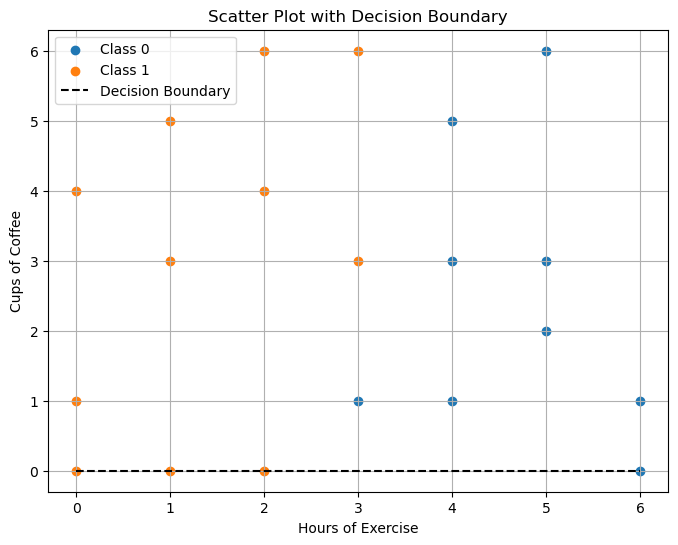

In [549]:
import matplotlib.pyplot as plt 

# define a function to plot data for the decision boundary
def decision_boundary(X, y, weights):
    plt.figure(figsize=(8, 6))

    # plot each scatter point
    for label in np.unique(y):
        subset = X[y == label]
        plt.scatter(subset[:, 1], subset[:, 2], label=f"Class {label}")

    # define the x & y vals of the decision boundary
    x_vals = np.linspace(0, 6, 100)
    y_vals = - (weights[0] + weights[1] * x_vals) / (weights[2] + 1e-6)
    plt.plot(x_vals, y_vals, 'k--', label="Decision Boundary")
    plt.xlabel("Hours of Exercise")
    plt.ylabel("Cups of Coffee")
    plt.title("Scatter Plot with Decision Boundary")
    plt.legend()
    plt.grid(True)
    plt.show()

decision_boundary(X, y, init_weights)

As we an see, our predictions are erroneous. We need a mechanism to make corrections on our weights, we need `gradient_descent`.

The `gradient_descent_update` function computes predictions using the current weights, calculates the error with respect to the true labels, and then updates the weights using full-batch gradient descent. The learning rate (`lr`) controls the step size for the update. 

In [550]:
def gradient_descent_update(X, y, weights, lr):
    """Performs one update of full-batch gradient descent on the weights.
    - X: Input feature matrix
    - y: True labels
    - weights: Current weight vector
    - lr: Learning rate
    Returns the updated weights."""
    preds = heaviside(perceptron_output(X, weights))
    error = y - preds
    delta = lr * np.dot(X.T, error) / X.shape[0]
    weights += delta
    return weights

In [551]:
# one iteration of full-batch gradient descent
learning_rate = 0.1

updated_weights = gradient_descent_update(X, y, init_weights, lr=learning_rate)
yhat = heaviside(perceptron_output(X, updated_weights))

print("New weights", updated_weights)
print("New predictions", yhat)

New weights [-0.045 -0.21  -0.11 ]
New predictions [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [552]:
error_rate = abs(sum(y - yhat) / len(y))

print("Current error rate:", error_rate)

Current error rate: 0.55


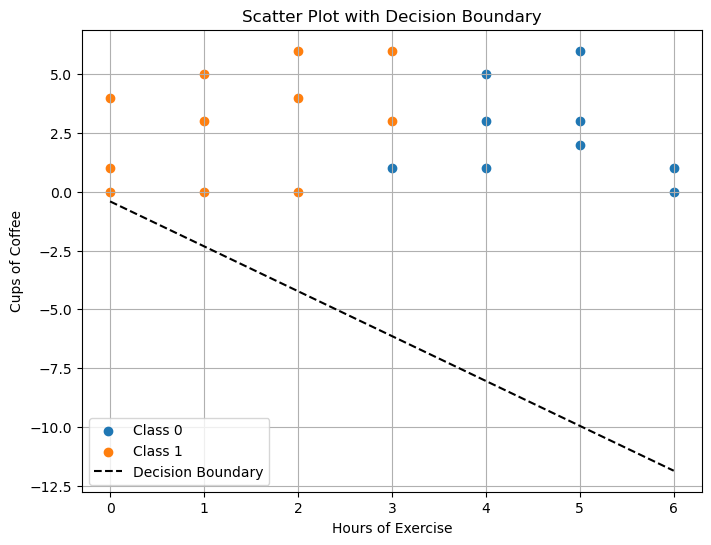

In [553]:
# plot decision boundary of updated weights
decision_boundary(X, y, updated_weights)

It seems like error rate isn't improving! Well, this is why gradient descent is an iterative proces..

Let's try out a few more runs (epochs) of gradient descent, and why don't we also try changing the `learning_rate` and `epochs` to see what happens to our final error rate.

In [554]:
# Initialize weights to zeros (one weight per feature)
weights = np.array([0.0, 0.0, 0.0])

# TODO: Change this learning rate to see how this hyperparameter influences training
learning_rate = 0.01
# TODO: Change the number of epochs see how training duration influences final error rate
epoch_count = 25

epochs = []
learned_weights = []
errors = []

for epoch in range(epoch_count):
    new_weights = gradient_descent_update(X, y, weights, lr=learning_rate)
    yhat = heaviside(perceptron_output(X, new_weights))
    error_rate = abs(sum(y - yhat) / len(y))

    print(f"Epoch {epoch}: Weights = {weights}")
    print("error rate = ", error_rate)

    epochs.append(epoch)
    learned_weights.append(new_weights)
    errors.append(error_rate)

Epoch 0: Weights = [-0.0045 -0.021  -0.011 ]
error rate =  0.55
Epoch 1: Weights = [ 0.001  -0.0135  0.005 ]
error rate =  0.25
Epoch 2: Weights = [ 0.0035 -0.008   0.0115]
error rate =  0.05
Epoch 3: Weights = [ 0.003  -0.013   0.0045]
error rate =  0.25
Epoch 4: Weights = [ 0.0055 -0.0075  0.011 ]
error rate =  0.1
Epoch 5: Weights = [ 0.0045 -0.015   0.0025]
error rate =  0.35
Epoch 6: Weights = [ 0.008  -0.008   0.0135]
error rate =  0.15
Epoch 7: Weights = [ 0.0065 -0.016   0.005 ]
error rate =  0.25
Epoch 8: Weights = [ 0.009  -0.0105  0.0115]
error rate =  0.05
Epoch 9: Weights = [ 0.0085 -0.0155  0.0045]
error rate =  0.25
Epoch 10: Weights = [ 0.011 -0.01   0.011]
error rate =  0.1
Epoch 11: Weights = [ 0.01   -0.0155  0.004 ]
error rate =  0.25
Epoch 12: Weights = [ 0.0125 -0.01    0.0105]
error rate =  0.1
Epoch 13: Weights = [ 0.0115 -0.0155  0.0035]
error rate =  0.25
Epoch 14: Weights = [ 0.014 -0.01   0.01 ]
error rate =  0.1
Epoch 15: Weights = [ 0.013  -0.0155  0.003 ]

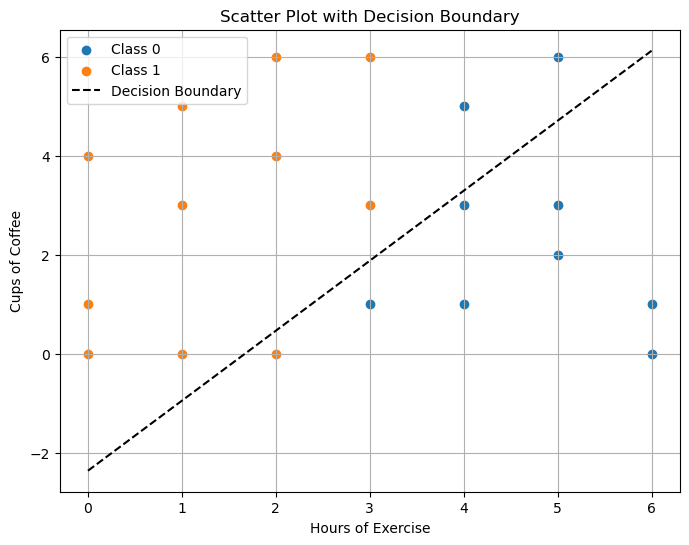

In [555]:
# plot decision boundary of final weights
decision_boundary(X, y, learned_weights[-1])

This training loop initializes the weight vector as zeros and then iteratively updates it using the full-batch gradient descent function. After each epoch, the updated weights are printed, illustrating how the model learns over time.

While this decision boundary might not be't perfect, note that training error is *largely* decreasing as we increase our epochs.

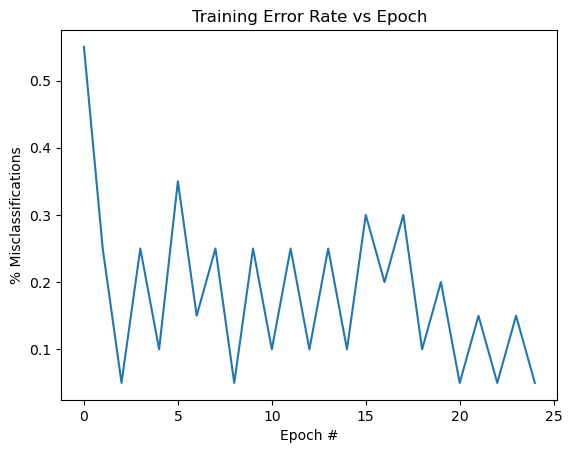

In [556]:
def plot_errors(epochs, errors):
    plt.plot(epochs, errors)
    plt.xlabel("Epoch #")
    plt.ylabel("% Misclassifications")
    plt.title("Training Error Rate vs Epoch")

plot_errors(epochs, errors)

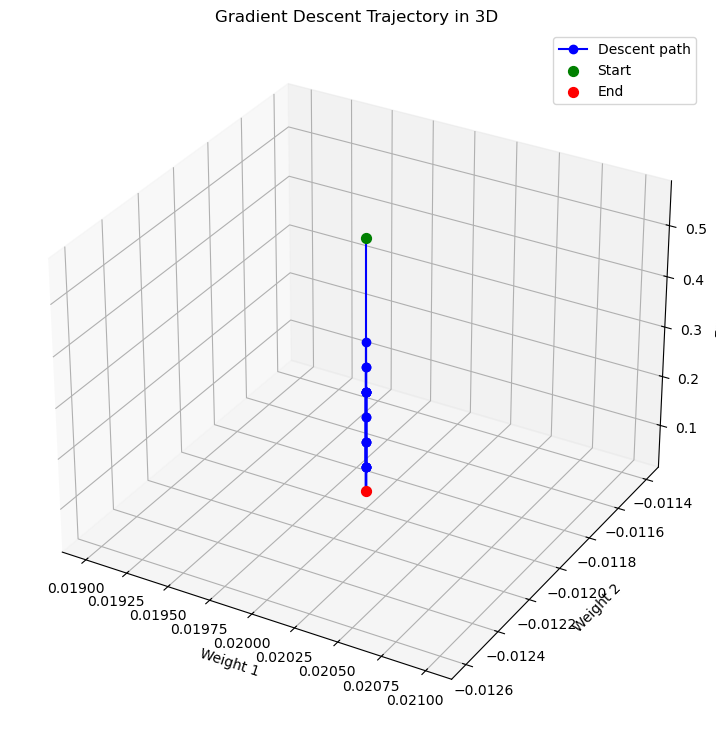

In [557]:
import matplotlib.pyplot as plt 

# create a function which plots the path of your full-batch gradient descent
def plot_descent(weights, errors):
    w1 = [w[0] for w in weights]
    w2 = [w[1] for w in weights]

    fig = plt.figure(figsize=(15, 9))
    ax = fig.add_subplot(111, projection='3d')

    # Plot the trajectory of gradient descent
    ax.plot(w1, w2, errors, marker='o', color='blue', label='Descent path')

    # Highlight start and end
    ax.scatter(w1[0], w2[0], errors[0], color='green', s=50, label='Start')
    ax.scatter(w1[-1], w2[-1], errors[-1], color='red', s=50, label='End')

    # Label axes
    ax.set_xlabel('Weight 1')
    ax.set_ylabel('Weight 2')
    ax.set_zlabel('Error')
    ax.set_title('Gradient Descent Trajectory in 3D')
    ax.legend()

    plt.show()

# plot full batch gradient descent
plot_descent(learned_weights, errors)

## Gradient Descent Variants using NumPy

Here we explore alternative gradient descent methods, including mini-batch and stochastic gradient descent.

### Mini-Batch Gradient Descent

In [558]:
def mini_batch_gradient_descent(X, y, weights, lr, batch_size):
    n, perm = X.shape[0], np.random.permutation(X.shape[0])
    X_shuf, y_shuf = X[perm], y[perm]
    for i in range(0, n, batch_size):
        xb, yb = X_shuf[i:i+batch_size], y_shuf[i:i+batch_size]
        p = heaviside(np.dot(xb, weights))
        e = yb - p
        dw = lr * np.dot(xb.T, e) / len(yb)
        weights += dw
    return weights

The `mini_batch_gradient_descent` function shuffles the dataset and divides it into mini-batches. For each mini-batch, it applies the gradient descent update. This approach can provide a balance between the stability of full-batch and the speed of stochastic gradient descent.

In [559]:
# Initialize weights to zeros (one weight per feature)
weights = np.array([0.0, 0.0, 0.0])

epochs = []
learned_weights = []
errors = []

for epoch in range(epoch_count):
    new_weights = mini_batch_gradient_descent(X, y, weights, lr=learning_rate, batch_size=4)
    yhat = heaviside(perceptron_output(X, new_weights))
    error_rate = abs(sum(y - yhat) / len(y))

    print(f"Epoch {epoch}: Weights = {weights}")
    print("error rate = ", error_rate)

    epochs.append(epoch)
    learned_weights.append(new_weights)
    errors.append(error_rate)

Epoch 0: Weights = [ 0.0075 -0.005   0.005 ]
error rate =  0.1
Epoch 1: Weights = [ 0.0125 -0.015   0.0025]
error rate =  0.3
Epoch 2: Weights = [ 0.015  -0.0225  0.0075]
error rate =  0.2
Epoch 3: Weights = [ 0.0175 -0.0225  0.0225]
error rate =  0.0
Epoch 4: Weights = [ 0.02   -0.0325  0.01  ]
error rate =  0.25
Epoch 5: Weights = [ 0.025  -0.0275  0.0125]
error rate =  0.15
Epoch 6: Weights = [ 0.0275 -0.025   0.0125]
error rate =  0.1
Epoch 7: Weights = [ 0.035  -0.0175  0.0375]
error rate =  0.3
Epoch 8: Weights = [ 0.03   -0.0425  0.02  ]
error rate =  0.15
Epoch 9: Weights = [ 0.035  -0.0375  0.02  ]
error rate =  0.15
Epoch 10: Weights = [ 0.04   -0.0325  0.015 ]
error rate =  0.1
Epoch 11: Weights = [ 0.0425 -0.03    0.01  ]
error rate =  0.1
Epoch 12: Weights = [ 0.0475 -0.035   0.015 ]
error rate =  0.1
Epoch 13: Weights = [ 0.0525 -0.0225  0.0225]
error rate =  0.25
Epoch 14: Weights = [ 5.00000000e-02 -4.00000000e-02 -1.04083409e-17]
error rate =  0.25
Epoch 15: Weights = 

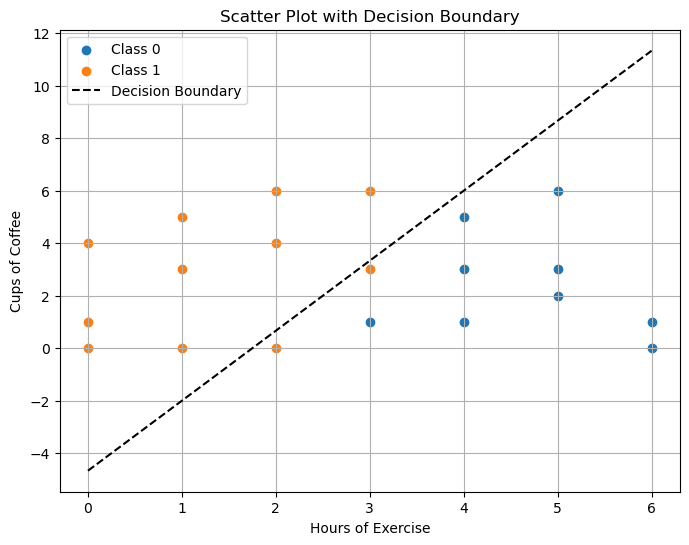

In [560]:
# plot final decision boundary
decision_boundary(X, y, learned_weights[-1])

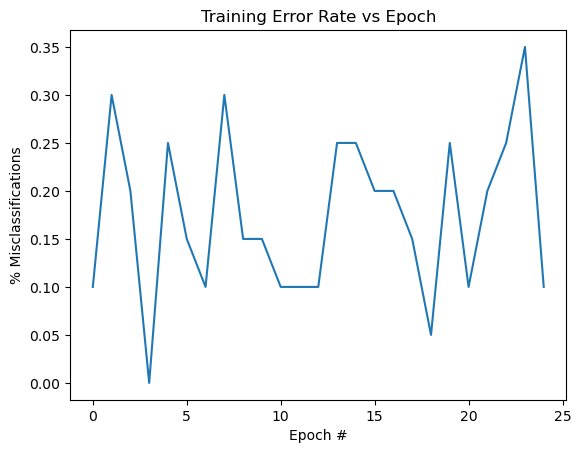

In [561]:
# plot errors of mini-batch
plot_errors(epochs, errors)

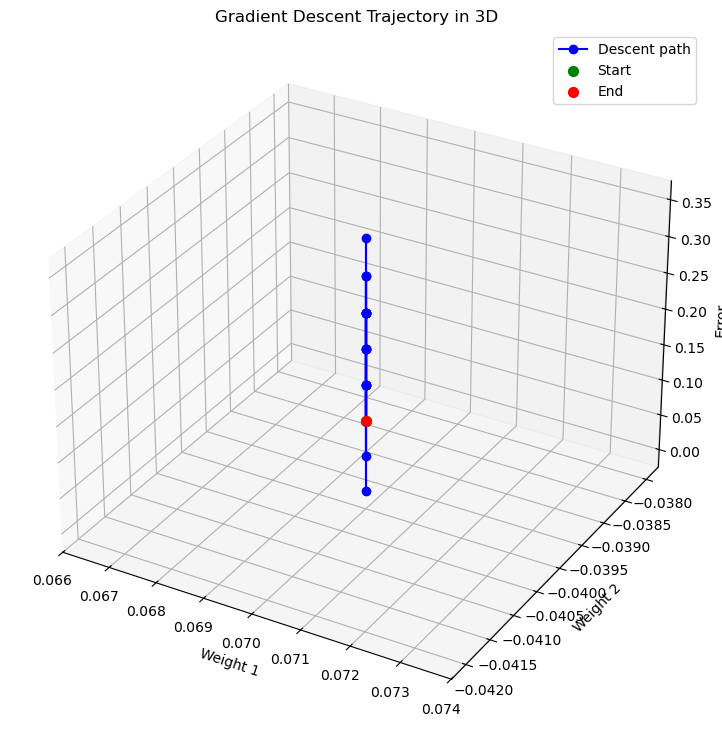

In [562]:
# plot the path of your mini-batch gradient descent
plot_descent(learned_weights, errors)

### Stochastic Gradient Descent

In [563]:
def stochastic_gradient_descent(X, y, weights, lr):
    n = X.shape[0]
    perm = np.random.permutation(n)
    X_shuf, y_shuf = X[perm], y[perm]
    for i in range(n):
        xi, yi = X_shuf[i], y_shuf[i]
        p = heaviside(np.dot(xi, weights))
        e = yi - p
        weights += lr * xi * e
    return weights

The `stochastic_gradient_descent` function updates the weights one sample at a time after shuffling the data. This method can potentially converge faster but may be noisier than the full-batch approach.

In [564]:
# Initialize weights to zeros (one weight per feature)
weights = np.array([0.0, 0.0, 0.0])

epochs = []
learned_weights = []
errors = []

for epoch in range(epoch_count):
    new_weights = stochastic_gradient_descent(X, y, weights, lr=learning_rate)
    yhat = heaviside(perceptron_output(X, new_weights))
    error_rate = abs(sum(y - yhat) / len(y))

    print(f"Epoch {epoch}: Weights = {weights}")
    print("error rate = ", error_rate)

    epochs.append(epoch)
    learned_weights.append(new_weights)
    errors.append(error_rate)

Epoch 0: Weights = [ 0.02 -0.06  0.03]
error rate =  0.15
Epoch 1: Weights = [ 0.03 -0.06  0.  ]
error rate =  0.4
Epoch 2: Weights = [ 0.05 -0.08  0.04]
error rate =  0.15
Epoch 3: Weights = [ 0.07 -0.07  0.04]
error rate =  0.15
Epoch 4: Weights = [ 0.09 -0.08  0.02]
error rate =  0.15
Epoch 5: Weights = [ 0.11 -0.07  0.02]
error rate =  0.1
Epoch 6: Weights = [ 0.12 -0.05  0.02]
error rate =  0.05
Epoch 7: Weights = [ 0.11 -0.09 -0.03]
error rate =  0.4
Epoch 8: Weights = [ 0.14 -0.08  0.05]
error rate =  0.05
Epoch 9: Weights = [ 0.15 -0.08  0.06]
error rate =  0.1
Epoch 10: Weights = [ 0.16 -0.08  0.07]
error rate =  0.1
Epoch 11: Weights = [ 0.17 -0.07  0.05]
error rate =  0.2
Epoch 12: Weights = [ 0.18 -0.09  0.06]
error rate =  0.1
Epoch 13: Weights = [ 0.19 -0.11  0.05]
error rate =  0.05
Epoch 14: Weights = [ 0.2  -0.13  0.04]
error rate =  0.1
Epoch 15: Weights = [ 0.21 -0.12  0.04]
error rate =  0.1
Epoch 16: Weights = [ 0.22 -0.12  0.03]
error rate =  0.1
Epoch 17: Weights

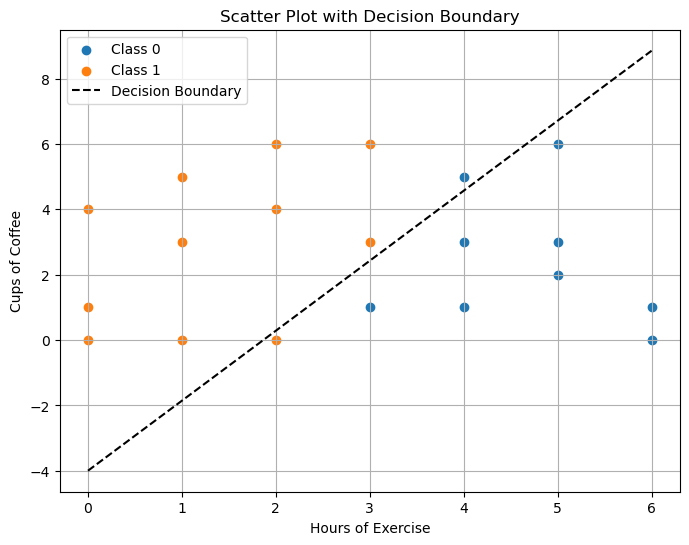

In [565]:
# plot final decision boundary
decision_boundary(X, y, learned_weights[-1])

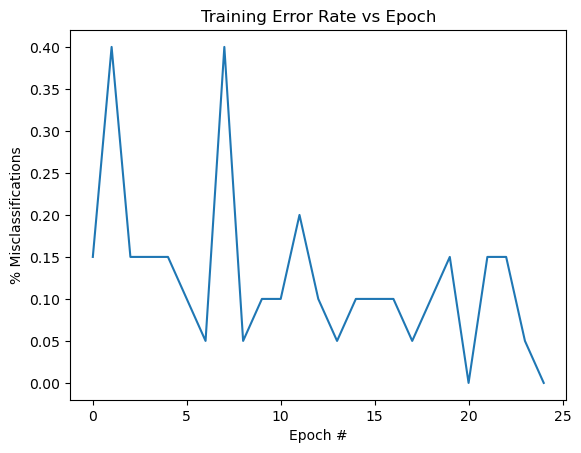

In [566]:
# plot errors of mini-batch
plot_errors(epochs, errors)

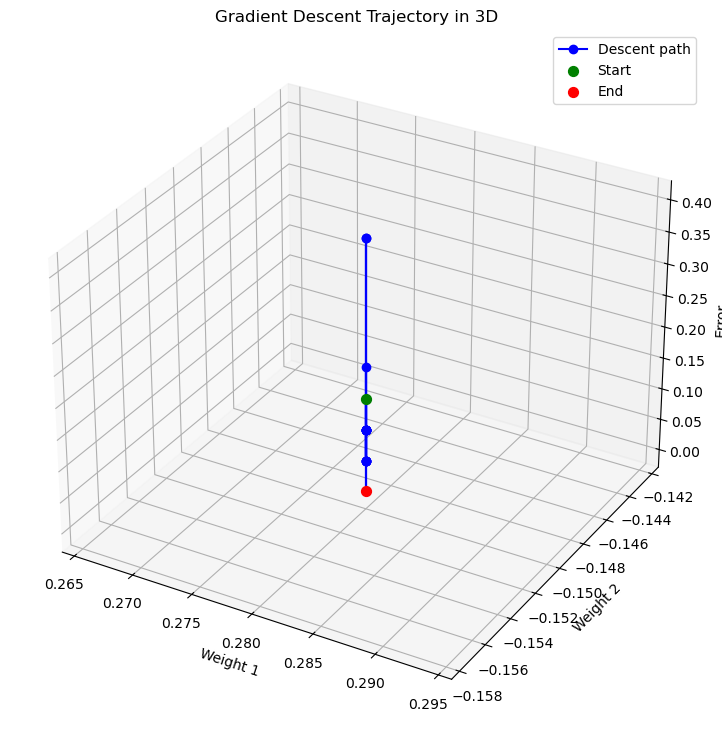

In [567]:
# plot the path of your stochastic gradient descent
plot_descent(learned_weights, errors)

## Multi-Layer Perceptrons using Numpy

In this section we use numpy to implement a multi-layer perceptron network on a non-linearaly seperable dataset. We will explore how using different activation functions (and more layers) give us the ability to classify datasets with non-linear boundaries.

In [589]:
import numpy as np

# define a non-linear dataset (with an added bias term)
X = np.array([
    [1, 2, 4], [1, 2.5, 4.5], [1, 3.0, 5.0], [1, 3.5, 4.5], [1, 4.0, 4.0],
    [1, 3.5, 3.5], [1, 4, 2], [1, 3.0, 3.0], [1, 2.5, 3.5], [1, 2.0, 4.0],
    [1, 3.0, 4.0], [1, 3.25, 4.25], [1, 2.75, 3.75], [1, 3.25, 3.75], [1, 2.75, 4.25]  
])

center = np.array([3, 4])
radius = 0.5

# label using circular rule: if inside radius → 1, else 0
features = X[:, 1:3]  
distances = np.linalg.norm(features - center, axis=1)
y = (distances < radius).astype(int)

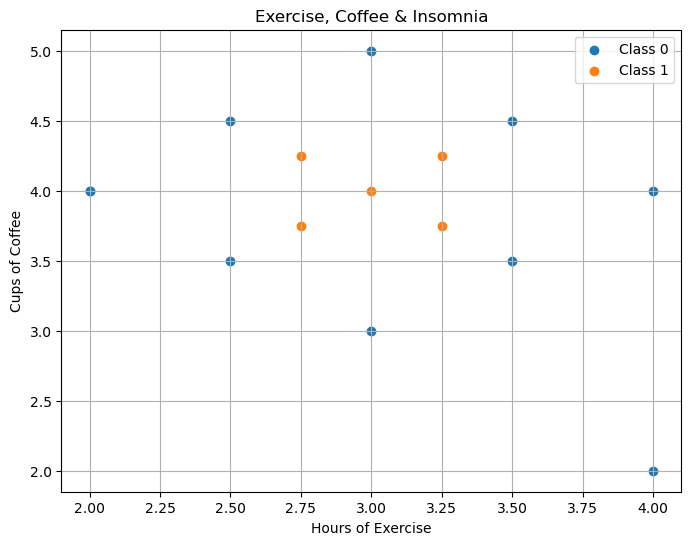

In [590]:
plt.figure(figsize=(8, 6))

# plot each scatter point
for label in np.unique(y):
    subset = X[y == label]
    plt.scatter(subset[:, 1], subset[:, 2], label=f"Class {label}")

plt.xlabel("Hours of Exercise")
plt.ylabel("Cups of Coffee")
plt.title("Exercise, Coffee & Insomnia")
plt.legend()
plt.grid(True)
plt.show()

Regardless of how many epochs we utilize or if our learning rate is "good" enough, we will never fit a linear boundary on a non-linear dataset.

To acheive non-linearity we must utilize a network of neurons, also known as multi-layer perceptron (MLP) to recognize the boundaries of our dataset and subsequently create one final non-linear decision boundaries.

Choosing the appropirate number of hidden layers & nodes within hidden layers is not a trivial task and cannot be answered simply. This often depends on your search space (the dataset) and how many classes we are aiming to categorize.

As a good rule of thumb, this [StackOverflow answer](https://stats.stackexchange.com/questions/181/how-to-choose-the-number-of-hidden-layers-and-nodes-in-a-feedforward-neural-netw) recommends the following rules:
* **The Input Layer**: This layer is completely dependent on the number of predictor our dataset has. So for example, if we have 10 columns within our dataset, we will also have 11 input nodes (+1 for the bias term).  
* **The Output Layer**: This layer is completely dependent on the amount of categories we are looking to predict. So if we have two categories in our dataset (e.g. `fraud` vs `not fraud`), we will have only two output nodes.  
* **The Hidden Layers**: As expressed in the post, we only need hidden layers if our dataset contains non-linear boundaries. Once we determine that we do need a hidden layer (most prediction tasks can be sufficiently solved with only one hidden layer), we can arbitrarily choose a number of nodes somewhere between the input size and the output size (as expressed by Jeff Heaton).  

For this machine learning task, we will use 3 input nodes, 2 hidden node, and 1 output node.

In [591]:
def forward_pass(X, W1, W2):
    """Performs a forward pass of the MLP"""
    Z1 = heaviside(perceptron_output(X, W1))         # Hidden layer activation
    Z2 = heaviside(perceptron_output(Z1, W2))       # Output layer activation
    return Z2

def initialize_weights(input_size, hidden_size, output_size):
    """Randomly initialize weights for input → hidden and hidden → output layers"""
    W1 = np.random.randn(input_size, hidden_size) * 0.1
    W2 = np.random.randn(hidden_size, output_size) * 0.1
    return W1, W2

In [593]:
input_nodes = 3
hidden_nodes = 2
output_size = 1

# initialize weights for both layers
W1, W2 = initialize_weights(input_nodes, hidden_nodes, output_size)

outputs = forward_pass(X, W1, W2)

print(outputs)

[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]


Just like before we need to train our model via gradient descent. However this time, since we are dealing with multiple layers of perceptrons, simple gradient descent will not work!

Iterating improvements on the output of our final layer of perceptrons does not gaurantee that our previous layer will see the same improvements. 

Instead, we must rely on the concept of [backpropagation](https://www.youtube.com/watch?v=IN2XmBhILt4&ab_channel=StatQuestwithJoshStarmer). 

In addition we should also utilize a non-linear activation function such as ReLU (rectified linear unit) or the sigmoid to model our non-linear boundaries.

In [594]:
def relu(x):
    """Applies the ReLU function element-wise on x. Returns x if x > 0, else 0."""
    return np.where(x > 0, x, 0)

def relu_derivative(x):
    return (x > 0).astype(float)

def sigmoid(x):
    """Applies the sigmoid function element-wise on x. Returns value between 0 and 1."""
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

In [595]:
# forward pass
def forward_pass(X, W1, W2):
    Z1 = perceptron_output(X, W1)
    A1 = relu(Z1)

    Z2 = perceptron_output(A1, W2)
    A2 = sigmoid(Z2)
    return Z1, A1, Z2, A2

# backward pass
def backward_pass(X, y, Z1, A1, Z2, A2, W1, W2, lr=0.1):
    m = y.shape[0]

    dZ2 = A2 - y                   # shape: (m, 1)
    dW2 = (A1.T @ dZ2) / m         # shape: (hidden, 1)

    dA1 = dZ2 @ W2.T               # shape: (m, hidden)
    dZ1 = dA1 * relu_derivative(Z1)  # shape: (m, hidden)
    dW1 = (X.T @ dZ1) / m          # shape: (input, hidden)

    # Gradient descent step
    W1 -= lr * dW1
    W2 -= lr * dW2

    return W1, W2

# loss function
def binary_cross_entropy(y_true, y_pred):
    # To avoid log(0), clip values
    y_pred = np.clip(y_pred, 1e-8, 1 - 1e-8)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [597]:
for epoch in range(epoch_count):
    Z1, A1, Z2, A2 = forward_pass(X, W1, W2)
    loss = binary_cross_entropy(y, A2)
    W1, W2 = backward_pass(X, y, Z1, A1, Z2, A2, W1, W2, lr=learning_rate)

    if epoch % 100 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch} | Loss: {loss:.4f}")

# Final predictions
print("\nFinal predictions:")
predictions = (A2 >= 0.5).astype(int)
for i in range(len(y)):
    print(f"Sample {i+1}: Pred={predictions[i][0]} | True={y[i][0]}")

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 1 is different from 15)

## Feed-Forward Neural Network using Keras

In this section we use Keras to implement a simple feed-forward neural network on the Olivetti faces dataset. The dataset contains 400 grayscale images (64x64 pixels) across 40 classes.

In [ ]:
!pip install tensorflow

In [568]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
import numpy as np

The cell above imports necessary modules from TensorFlow and scikit-learn. We will use Keras (via TensorFlow) to define and train our neural network, and scikit-learn to load and split the dataset.

In [601]:
data = fetch_olivetti_faces()

X_faces = data.images.reshape((data.images.shape[0], -1))  # Flatten the images
y_faces = data.target

X_train, X_test, y_train, y_test = train_test_split(X_faces, y_faces, test_size=0.2, random_state=42)

This cell loads the Olivetti faces dataset and reshapes the images from 64x64 matrices to flat vectors. The data is then split into training and testing sets.

Keras basics...

In [602]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(40, activation='softmax')
])

c:\Users\saidmf\anaconda3\envs\ds\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


A simple feed-forward neural network is defined here. The network has an input layer matching the flattened image size, two hidden layers with ReLU activation, and an output layer with softmax activation to classify the 40 classes.

In [603]:
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=100, validation_split=0.2, verbose=True)

Epoch 1/100


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.0396 - loss: 4.2182 - val_accuracy: 0.0156 - val_loss: 3.8424
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0555 - loss: 3.7488 - val_accuracy: 0.0312 - val_loss: 3.7361
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0425 - loss: 3.7108 - val_accuracy: 0.0156 - val_loss: 3.7586
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0535 - loss: 3.6603 - val_accuracy: 0.0469 - val_loss: 3.7332
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0442 - loss: 3.6463 - val_accuracy: 0.0156 - val_loss: 3.7585
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0463 - loss: 3.6405 - val_accuracy: 0.0312 - val_loss: 3.7318
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0555 - loss: 3.6299 - val_accuracy: 0.0781 - val_loss: 3.7605
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1126 - loss: 3.5973 - val_accuracy: 0.0000e+00 - val_loss: 3.6958


The model is compiled using the Adam optimizer and trained using sparse categorical crossentropy loss. The training is run for 10 epochs with a validation split of 20%. 

**Challenge:** Try altering the number of training epochs or using a different optimizer (for example, SGD) and observe how the validation accuracy changes.

In [609]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=True)
print("Test Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6047 - loss: 1.4605
Test Accuracy: 0.6000000238418579


This cell evaluates the trained model on the test set and prints the test accuracy, providing an overall metric for the model's performance on unseen data.

In [611]:
yhat = model.predict(X_test)

yhat

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


array([[7.2485358e-02, 2.6386680e-09, 2.8229007e-03, ..., 8.9412043e-04,
        1.2309087e-03, 7.6070957e-02],
       [2.1930940e-02, 2.3483418e-08, 7.4086660e-03, ..., 3.4515545e-02,
        2.3490356e-02, 7.1261242e-02],
       [8.3643675e-02, 6.6169567e-05, 4.5173585e-02, ..., 1.2936193e-05,
        4.7437754e-04, 4.4403665e-04],
       ...,
       [9.1064337e-08, 2.2115469e-08, 3.9606486e-05, ..., 6.5238337e-06,
        1.0630350e-02, 3.0610639e-10],
       [1.5934117e-01, 8.1640766e-10, 1.6034995e-03, ..., 6.5839158e-05,
        3.9438579e-05, 8.4085785e-02],
       [1.2928419e-02, 8.2967300e-10, 1.0482135e-02, ..., 1.9926435e-01,
        5.7733068e-03, 1.3346651e-01]], dtype=float32)

In [ ]:
X_images = data.images

_, _, _, _, _, idx_test = train_test_split(
    X_faces, data.target, np.arange(len(data.images)),
    test_size=0.3, random_state=42
)

# Step 2: Visualize predictions with true labels
n_samples_to_plot = 16
sample_idxs = np.random.choice(len(yhat), n_samples_to_plot, replace=False)

plt.figure(figsize=(15, 6))
for i, idx in enumerate(sample_idxs):
    img = X_images[idx_test[idx]]
    true_label = y_test[idx]
    pred_label = yhat[idx]

    plt.subplot(4, 4, i + 1)
    plt.imshow(img, cmap='gray')
    title_color = 'green' if true_label == pred_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=title_color, fontsize=10)
    plt.axis('off')

plt.suptitle("Olivetti Faces – True vs Predicted (kNN)", fontsize=16)
plt.tight_layout()
plt.show()

## Alternative Activations and Intermediate Outputs using Keras

Here we experiment with alternative activation functions and different numbers of intermediate nodes. We also extract outputs from intermediate layers to study what features the network is learning.

In [605]:
model_alt = Sequential([
    Dense(256, activation='tanh', input_shape=(X_train.shape[1],)),
    Dense(128, activation='tanh'),
    Dense(64, activation='relu'),
    Dense(40, activation='softmax')
])

An alternative model is constructed with a different configuration: increased number of nodes and the use of the `tanh` activation function in the first two layers. This change may provide different feature representations compared to the original model.

**Challenge:** Experiment by further altering the number of nodes or changing the activation functions in this architecture.

In [606]:
model_alt.compile(optimizer='adam', 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])

history_alt = model_alt.fit(X_train, y_train, epochs=10, validation_split=0.2, verbose=0)

The alternative model is compiled and trained similarly to the previous model. The training history can be used to compare performance between architectures.

In [607]:
from tensorflow.keras.models import Model

# Create a new model that outputs the output of the second layer
intermediate_model = Model(inputs=model_alt.input, outputs=model_alt.layers[1].output)
intermediate_output = intermediate_model.predict(X_test[:5])
print("Intermediate layer output sample:", intermediate_output)

AttributeError: The layer sequential_38 has never been called and thus has no defined input.

In this cell we extract the output from an intermediate layer (the second layer) of the alternative model. This helps in understanding which features are being activated and how the network processes the input data.

**Challenge:** Try extracting outputs from different layers, or modify the model architecture further to see how the intermediate representations change.